In [1]:
from __future__ import annotations

import re
from pathlib import Path
from typing import Any, Dict, Optional, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# USER SETTINGS
# =========================
RESULTS_ROOT = Path('../results').resolve()   # change if needed
OUT_DIR = Path('./comparison_out').resolve()
OUT_DIR.mkdir(parents=True, exist_ok=True)

BUCKET_SEC = 30
SLA_MS = 800


RUN_FILTER_REGEX = None  

print('RESULTS_ROOT =', RESULTS_ROOT)
print('OUT_DIR      =', OUT_DIR)


RESULTS_ROOT = /Users/soheila/Desktop/RealTime-Streaming-Pipeline/results
OUT_DIR      = /Users/soheila/Desktop/RealTime-Streaming-Pipeline/analysis/comparison_out


In [2]:
# =========================
# Helpers
# =========================
def safe_float(x: Any) -> Optional[float]:
    try:
        if x is None:
            return None
        if isinstance(x, str) and x.strip() == '':
            return None
        return float(x)
    except Exception:
        return None

def read_configmap_params(cfg_path: Path) -> Dict[str, Any]:
    """Minimal parsing for ConfigMap YAML values under `data:`."""
    params = {'traffic_mode': 'unknown', 'skew_fraction': None, 'skew_partitions': None}
    if not cfg_path.exists():
        return params

    in_data = False
    for raw in cfg_path.read_text(encoding='utf-8', errors='ignore').splitlines():
        line = raw.rstrip('\n')
        if re.match(r'^\s*data\s*:\s*$', line):
            in_data = True
            continue
        if in_data and re.match(r'^\S', line):
            in_data = False
        if not in_data:
            continue

        m = re.match(r'^\s*([A-Za-z0-9_]+)\s*:\s*(.*)\s*$', line)
        if not m:
            continue
        k = m.group(1).strip()
        v = m.group(2).strip().strip('"').strip("'")

        if k == 'TRAFFIC_MODE':
            params['traffic_mode'] = (v or 'unknown').lower()
        elif k in ('SKEW_FRACTION','SKEW_FRAC','SKEWFRAC'):
            params['skew_fraction'] = safe_float(v)
        elif k in ('SKEW_PARTITIONS','SKEW_PARTITION','SKEW_PARTS'):
            nums = re.findall(r'-?\d+', v)
            params['skew_partitions'] = ','.join(nums) if nums else v
    return params

def extract_consumer_pod_from_name(fname: str) -> str:
    m = re.search(r'(consumer-sts-\d+)', fname)
    return m.group(1) if m else 'unknown'

def auto_to_seconds(ts: pd.Series) -> pd.Series:
    """Convert epoch timestamps to seconds if they look like ms."""
    ts = pd.to_numeric(ts, errors='coerce')
    med = ts.dropna().median()
    if pd.isna(med):
        return ts
    return ts / 1000.0 if float(med) > 1e11 else ts


In [3]:
# =========================
# Loaders
# =========================
def load_consumer_metrics_run(run_dir: Path) -> pd.DataFrame:
    """Load all consumer_metrics_run-*.csv across consumer pods for a run."""
    consumer_dir = run_dir / 'consumer'
    files = sorted(consumer_dir.glob('consumer-sts-*_metrics/consumer_metrics_run-*_consumer-sts-*.csv'))
    if not files:
        return pd.DataFrame()

    frames = []
    for f in files:
        df = pd.read_csv(f)
        df['pod'] = extract_consumer_pod_from_name(f.name)
        df['__file'] = str(f)
        frames.append(df)

    m = pd.concat(frames, ignore_index=True)
    return m

def load_per_message_run(run_dir: Path) -> pd.DataFrame:
    """Load all per-message files across consumer pods for a run.
    Expected at least: recv_ts, e2e_ms, partition.
    """
    consumer_dir = run_dir / 'consumer'
    files = sorted(consumer_dir.glob('consumer-sts-*_metrics/per_message_latency_run-*_consumer-sts-*.csv'))
    if not files:
        return pd.DataFrame()

    frames = []
    for f in files:
        df = pd.read_csv(f)
        if 'recv_ts' not in df.columns or 'e2e_ms' not in df.columns or 'partition' not in df.columns:
            raise ValueError(f'{f} missing required columns (recv_ts, e2e_ms, partition)')
        df['consumer_pod'] = extract_consumer_pod_from_name(f.name)
        df['__file'] = str(f)
        frames.append(df)

    lat = pd.concat(frames, ignore_index=True)
    lat['recv_ts'] = pd.to_numeric(lat['recv_ts'], errors='coerce')
    lat['e2e_ms'] = pd.to_numeric(lat['e2e_ms'], errors='coerce')
    lat['partition'] = pd.to_numeric(lat['partition'], errors='coerce').astype('Int64')
    lat = lat.dropna(subset=['recv_ts','e2e_ms','partition'])
    return lat


In [4]:
# =========================
# Build run time-series from consumer_metrics (truth for throughput)
# =========================
def build_ts_from_consumer_metrics(m: pd.DataFrame, bucket_sec: int) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """Return (cluster_ts, pod_summary) from consumer_metrics_run.

    Required columns (from your consumer_metrics sample):
    - uptime_sec
    - msg_rate_window
    - lat_p99_ms
    - window_total, window_viol (or viol_rate)
    - lag_skew_ratio (optional)
    """
    if m.empty:
        return pd.DataFrame(), {}

    # normalize numeric
    for c in ['uptime_sec','lat_window_seconds','msg_rate_window','lat_p99_ms','window_total','window_viol','viol_rate','lag_skew_ratio']:
        if c in m.columns:
            m[c] = pd.to_numeric(m[c], errors='coerce')

    if 'uptime_sec' not in m.columns:
        raise ValueError('consumer_metrics missing uptime_sec')

    # Derive t_bucket from uptime_sec
    m = m.dropna(subset=['uptime_sec']).copy()
    m['t_bucket'] = (np.floor(m['uptime_sec'] / bucket_sec) * bucket_sec).astype(int)

    # Cluster aggregation per bucket
    grp = m.groupby('t_bucket', dropna=True)
    out = pd.DataFrame({'t_bucket': sorted(grp.groups.keys())})

    # throughput: sum across pods (msg_rate_window is msg/s per pod)
    if 'msg_rate_window' in m.columns:
        out['throughput'] = grp['msg_rate_window'].sum(min_count=1)

    # p99 across pods: max and median of per-pod p99
    if 'lat_p99_ms' in m.columns:
        out['p99_pods_max_ms'] = grp['lat_p99_ms'].max()
        out['p99_pods_med_ms'] = grp['lat_p99_ms'].median()

    # SLA violation: prefer window_viol/window_total at cluster level
    if 'window_total' in m.columns and 'window_viol' in m.columns:
        tot = grp['window_total'].sum(min_count=1)
        vio = grp['window_viol'].sum(min_count=1)
        out['viol_rate'] = (vio / tot).replace([np.inf, -np.inf], np.nan)
    elif 'viol_rate' in m.columns:
        out['viol_rate'] = grp['viol_rate'].mean()

    # lag skew ratio (already cluster-ish per pod; take mean or max; mean is smoother)
    if 'lag_skew_ratio' in m.columns:
        out['lag_skew_ratio'] = grp['lag_skew_ratio'].mean()

    out = out.sort_values('t_bucket').reset_index(drop=True)

    # Pod-level hot consumer from per-pod mean p99
    pod_summary = {}
    if 'lat_p99_ms' in m.columns and 'pod' in m.columns:
        s = m.groupby('pod')['lat_p99_ms'].mean().dropna().sort_values(ascending=False)
        if len(s) > 0:
            pod_summary['hot_consumer'] = str(s.index[0])
            pod_summary['hot_consumer_p99_mean_ms'] = float(s.iloc[0])

    return out, pod_summary


In [5]:
# =========================
# Hot partition + true p99 (sampled) from per-message files
# =========================
def build_partition_metrics_from_permsg(lat: pd.DataFrame, bucket_sec: int, sla_ms: float) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """Return (permsg_ts, part_summary).

    permsg_ts columns:
      t_bucket, true_p99_ms, true_max_ms, true_viol_rate, hot_part_p99_ms
    """
    if lat.empty:
        return pd.DataFrame(), {'hot_partition': None, 'hot_partition_p99_mean_ms': None, 'skew_ratio_overall': None}

    lat = lat.copy()
    recv_sec = auto_to_seconds(lat['recv_ts'])
    t0 = float(recv_sec.min())
    lat['t_bucket'] = (np.floor((recv_sec - t0) / bucket_sec) * bucket_sec).astype(int)

    # hot partition: by total count
    counts = lat.groupby('partition').size().sort_values(ascending=False)
    hot_part = int(counts.index[0]) if len(counts) else None

    # overall skew ratio by counts
    skew_overall = None
    if len(counts) > 0 and float(counts.mean()) > 0:
        skew_overall = float(counts.max() / counts.mean())

    def bucket_stats(g: pd.DataFrame) -> pd.Series:
        arr = g['e2e_ms'].to_numpy()
        return pd.Series({
            'true_p99_ms': float(np.quantile(arr, 0.99)) if len(arr) else np.nan,
            'true_max_ms': float(np.max(arr)) if len(arr) else np.nan,
            'true_viol_rate': float(np.mean(arr > sla_ms)) if len(arr) else np.nan,
        })

    ts = lat.groupby('t_bucket').apply(bucket_stats).reset_index().sort_values('t_bucket').reset_index(drop=True)

    # hot partition p99 per bucket
    hot_p99_mean = None
    if hot_part is not None:
        hp = lat[lat['partition'] == hot_part]
        if not hp.empty:
            def hp_p99(g: pd.DataFrame) -> pd.Series:
                arr = g['e2e_ms'].to_numpy()
                return pd.Series({'hot_part_p99_ms': float(np.quantile(arr, 0.99)) if len(arr) else np.nan})
            hp_ts = hp.groupby('t_bucket').apply(hp_p99).reset_index()
            ts = ts.merge(hp_ts, on='t_bucket', how='left')
            v = ts['hot_part_p99_ms'].dropna()
            if len(v) > 0:
                hot_p99_mean = float(v.mean())

    part_summary = {
        'hot_partition': hot_part,
        'hot_partition_p99_mean_ms': hot_p99_mean,
        'permsg_skew_ratio_overall': skew_overall,
        'permsg_n_samples': int(len(lat)),
    }
    return ts, part_summary


In [6]:
# =========================
# Load all runs and build hybrid tables
# =========================
run_dirs = sorted([p for p in RESULTS_ROOT.iterdir() if p.is_dir() and (p/'consumer').exists()])
if RUN_FILTER_REGEX:
    pat = re.compile(RUN_FILTER_REGEX)
    run_dirs = [p for p in run_dirs if pat.search(p.name)]

all_ts = []
all_rows = []

for rd in run_dirs:
    cfg = read_configmap_params(rd / 'consumer' / 'pipeline-configmap.yaml')
    tm = cfg.get('traffic_mode','unknown')
    sf = cfg.get('skew_fraction', None)
    sp = cfg.get('skew_partitions', None)
    sf_s = f"{sf:.2f}" if isinstance(sf,(int,float)) else 'na'
    sp_s = str(sp) if sp is not None else 'na'
    label = f"{rd.name} | tm={tm} sf={sf_s} sp={sp_s}"

    m = load_consumer_metrics_run(rd)
    ts_m, pod_summ = build_ts_from_consumer_metrics(m, BUCKET_SEC) if not m.empty else (pd.DataFrame(), {})

    lat = load_per_message_run(rd)
    ts_p, part_summ = build_partition_metrics_from_permsg(lat, BUCKET_SEC, SLA_MS) if not lat.empty else (pd.DataFrame(), {'hot_partition': None, 'hot_partition_p99_mean_ms': None, 'permsg_skew_ratio_overall': None, 'permsg_n_samples': 0})

    if ts_m.empty and ts_p.empty:
        print('[WARN] no inputs for', rd.name)
        continue

    # Merge on t_bucket (outer) so we can plot metrics + true p99 together
    if ts_m.empty:
        ts = ts_p.copy()
    elif ts_p.empty:
        ts = ts_m.copy()
    else:
        ts = ts_m.merge(ts_p, on='t_bucket', how='outer')

    ts = ts.sort_values('t_bucket').reset_index(drop=True)
    ts['run_id'] = rd.name
    ts['label'] = label
    ts['traffic_mode'] = tm
    ts['skew_fraction'] = sf
    ts['skew_partitions'] = sp
    ts['hot_partition'] = part_summ.get('hot_partition')
    ts['hot_consumer'] = pod_summ.get('hot_consumer')
    all_ts.append(ts)

    # Summary row
    row = {
        'run_id': rd.name,
        'traffic_mode': tm,
        'skew_fraction': sf,
        'skew_partitions': sp,
        **pod_summ,
        **part_summ,
    }
    # overall averages from consumer_metrics ts
    if not ts_m.empty:
        if 'throughput' in ts_m.columns:
            row['throughput_mean_msg_s'] = float(pd.to_numeric(ts_m['throughput'], errors='coerce').dropna().mean())
        if 'p99_pods_max_ms' in ts_m.columns:
            row['p99_pods_max_mean_ms'] = float(pd.to_numeric(ts_m['p99_pods_max_ms'], errors='coerce').dropna().mean())
        if 'viol_rate' in ts_m.columns:
            row['viol_rate_mean'] = float(pd.to_numeric(ts_m['viol_rate'], errors='coerce').dropna().mean())
        if 'lag_skew_ratio' in ts_m.columns:
            row['lag_skew_ratio_mean'] = float(pd.to_numeric(ts_m['lag_skew_ratio'], errors='coerce').dropna().mean())
    # overall true p99 mean
    if not ts_p.empty and 'true_p99_ms' in ts_p.columns:
        row['true_p99_mean_ms'] = float(pd.to_numeric(ts_p['true_p99_ms'], errors='coerce').dropna().mean())

    all_rows.append(row)

hybrid_ts = pd.concat(all_ts, ignore_index=True) if all_ts else pd.DataFrame()
hybrid_summary = pd.DataFrame(all_rows)

print('Runs loaded:', len(hybrid_summary))
hybrid_summary.sort_values(['traffic_mode','skew_fraction'], na_position='last')

[WARN] no inputs for 20260224_010759_skew
Runs loaded: 4


,run_id,traffic_mode,skew_fraction,skew_partitions,hot_consumer,hot_consumer_p99_mean_ms,hot_partition,hot_partition_p99_mean_ms,permsg_skew_ratio_overall,permsg_n_samples,throughput_mean_msg_s,p99_pods_max_mean_ms,viol_rate_mean,lag_skew_ratio_mean,true_p99_mean_ms
2,20260224_003023_balanced,balanced,NaN,,consumer-sts-3,932.104261,58,177.687192,1.225416,3966,97.283333,3163.423000,0.067329,2.624448,807.454918
0,20260223_232437_skew,skew,0.3,0,consumer-sts-0,288646.962763,0,291500.750998,15.841738,7734,190.394445,8763.838333,0.324195,2.568730,288331.194699
3,20260224_010612_skew,skew,0.3,0,consumer-sts-5,173434.914589,0,174824.510751,15.239554,4571,90.300001,4526.050000,0.405500,2.753333,174671.808335
1,20260223_235807_skew,skew,0.8,0,consumer-sts-3,503018.385302,0,510065.308158,35.994876,2342,41.816667,12673.618000,0.644480,3.154465,509960.017024


In [7]:
# Save tables
ts_path = OUT_DIR / 'hybrid_timeseries_long.csv'
sum_path = OUT_DIR / 'hybrid_summary.csv'

hybrid_ts.to_csv(ts_path, index=False)
hybrid_summary.to_csv(sum_path, index=False)

print('[OK] wrote', ts_path)
print('[OK] wrote', sum_path)


[OK] wrote /Users/soheila/Desktop/RealTime-Streaming-Pipeline/analysis/comparison_out/hybrid_timeseries_long.csv
[OK] wrote /Users/soheila/Desktop/RealTime-Streaming-Pipeline/analysis/comparison_out/hybrid_summary.csv


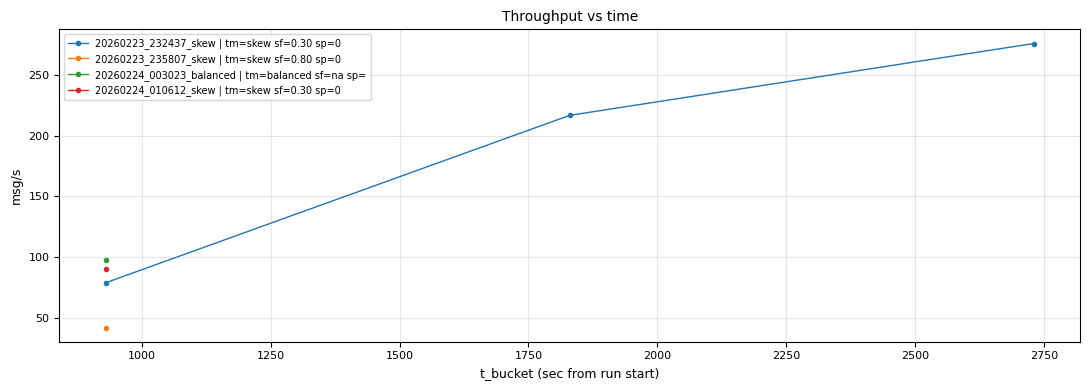

[OK] saved /Users/soheila/Desktop/RealTime-Streaming-Pipeline/analysis/comparison_out/hybrid_lines_throughput.pdf


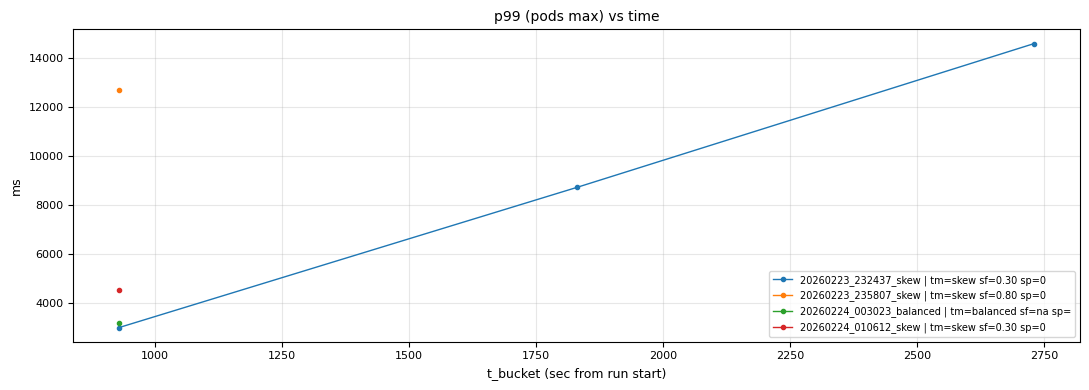

[OK] saved /Users/soheila/Desktop/RealTime-Streaming-Pipeline/analysis/comparison_out/hybrid_lines_p99_pods_max.pdf


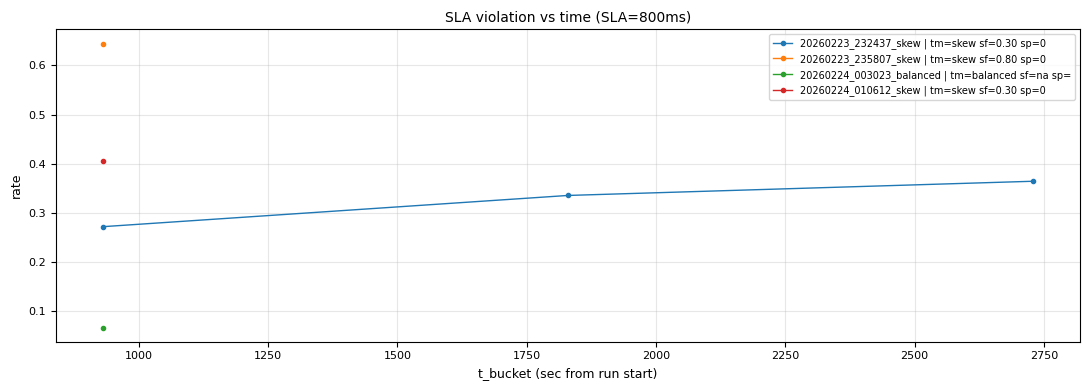

[OK] saved /Users/soheila/Desktop/RealTime-Streaming-Pipeline/analysis/comparison_out/hybrid_lines_violation.pdf


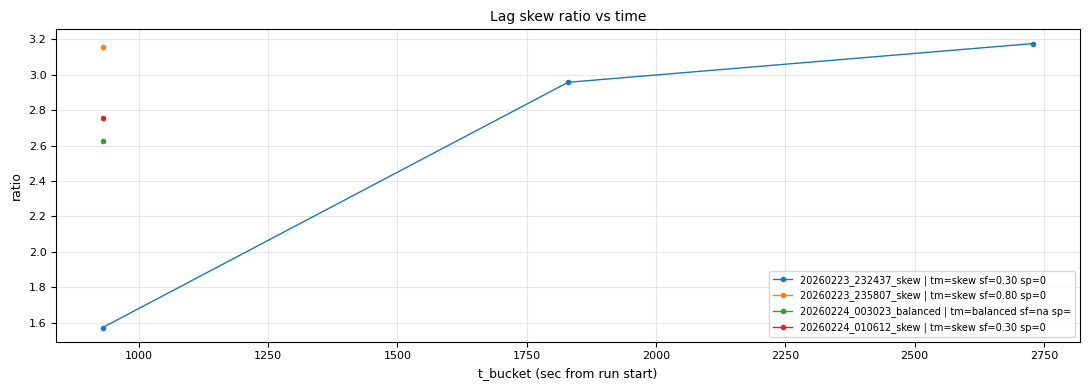

[OK] saved /Users/soheila/Desktop/RealTime-Streaming-Pipeline/analysis/comparison_out/hybrid_lines_lag_skew_ratio.pdf


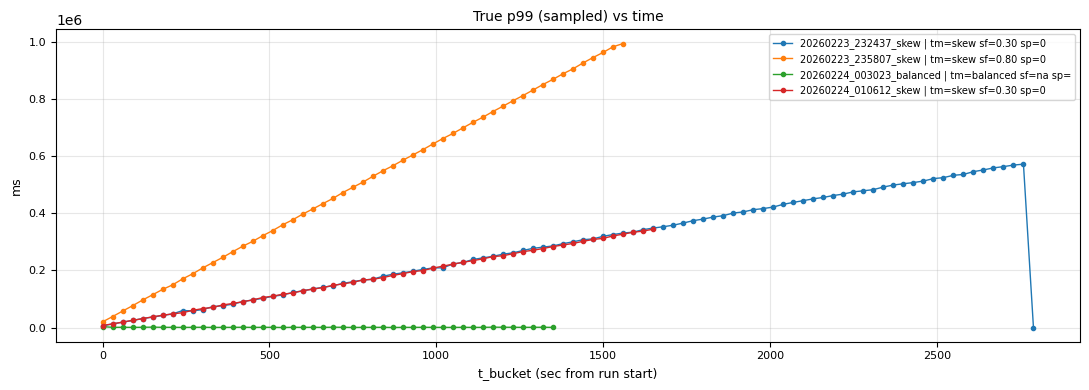

[OK] saved /Users/soheila/Desktop/RealTime-Streaming-Pipeline/analysis/comparison_out/hybrid_lines_true_p99.pdf


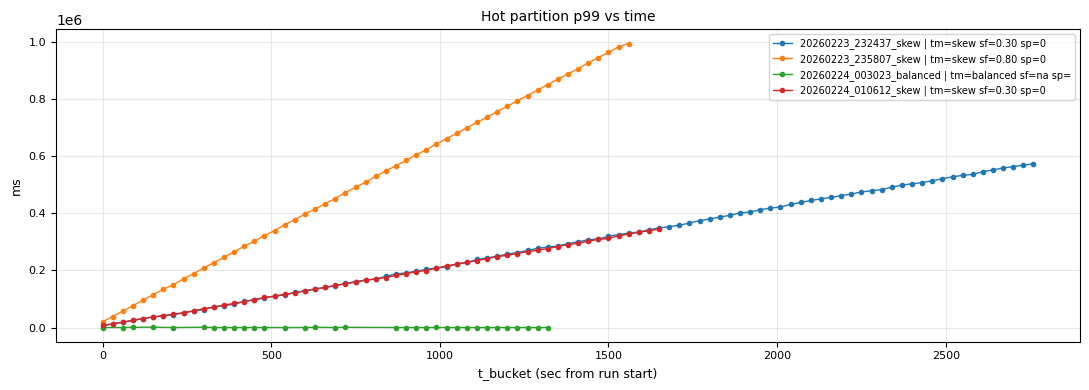

[OK] saved /Users/soheila/Desktop/RealTime-Streaming-Pipeline/analysis/comparison_out/hybrid_lines_hot_partition_p99.pdf


In [8]:
# =========================
# Line plots (compare runs by t_bucket)
# =========================
def line_compare(metric: str, title: str, ylab: str, out_pdf: str):
    if hybrid_ts.empty:
        print('[WARN] no time series to plot')
        return
    if metric not in hybrid_ts.columns:
        print('[WARN] metric not found:', metric)
        return

    fig = plt.figure(figsize=(11, 4))
    ax = fig.add_subplot(111)

    for label, g in hybrid_ts[['t_bucket','label',metric]].dropna().groupby('label'):
        g = g.sort_values('t_bucket')
        ax.plot(g['t_bucket'], g[metric], label=label, marker='o', markersize=3, linewidth=1)

    ax.set_title(title, fontsize=10)
    ax.set_xlabel('t_bucket (sec from run start)', fontsize=9)
    ax.set_ylabel(ylab, fontsize=9)
    ax.tick_params(axis='both', labelsize=8)
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.3)
    fig.tight_layout()

    out = OUT_DIR / out_pdf
    fig.savefig(out, dpi=200)
    plt.show()
    plt.close(fig)
    print('[OK] saved', out)

# Truth from consumer_metrics
line_compare('throughput', 'Throughput vs time', 'msg/s', 'hybrid_lines_throughput.pdf')
line_compare('p99_pods_max_ms', 'p99 (pods max) vs time', 'ms', 'hybrid_lines_p99_pods_max.pdf')
line_compare('viol_rate', f'SLA violation vs time (SLA={SLA_MS}ms)', 'rate', 'hybrid_lines_violation.pdf')
line_compare('lag_skew_ratio', 'Lag skew ratio vs time', 'ratio', 'hybrid_lines_lag_skew_ratio.pdf')

# From per-message (sampled)
line_compare('true_p99_ms', 'True p99 (sampled) vs time', 'ms', 'hybrid_lines_true_p99.pdf')
line_compare('hot_part_p99_ms', 'Hot partition p99 vs time', 'ms', 'hybrid_lines_hot_partition_p99.pdf')


In [ ]:
# Quick summary view
cols = [
    'run_id','traffic_mode','skew_fraction','skew_partitions',
    'throughput_mean_msg_s','p99_pods_max_mean_ms','viol_rate_mean','lag_skew_ratio_mean',
    'hot_consumer','hot_consumer_p99_mean_ms',
    'hot_partition','hot_partition_p99_mean_ms','permsg_n_samples','true_p99_mean_ms'
]
cols = [c for c in cols if c in hybrid_summary.columns]
hybrid_summary[cols].sort_values(['traffic_mode','skew_fraction'], na_position='last')

In [9]:
hybrid_ts.groupby('run_id')['t_bucket'].nunique()

run_id
20260223_232437_skew        95
20260223_235807_skew        54
20260224_003023_balanced    47
20260224_010612_skew        57
Name: t_bucket, dtype: int64